In [1]:
import importlib
from tqdm.auto import tqdm
import os
import pickle

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import torch
import transformers
from transformers import AutoTokenizer, AutoModel
import numpy as np 
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd

from safetensors.torch import load_model
from model import GenderChunkedClassifier

from viz_utils import plot_error_bar, plot_violins
from inference_utils import infer, load_generated_output, find_threshold_for_N, calculate_metrics

/home/jovyan/chepurova/dnalm/downstream_tasks/gender_classification/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = AutoTokenizer.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t')
model = AutoModel.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t', trust_remote_code=True)
model_module = importlib.import_module(model.__class__.__module__)
cls = getattr(model_module, 'BertModel')
model = cls.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t', add_pooling_layer=False)

gender_model = GenderChunkedClassifier(model)


load_model(gender_model,
           
           '/home/jovyan/chepurova/dnalm/downstream_tasks/gender_classification/runs/human_and_mouse_fixed_chromosome_ratios_16x3072_bs_128_lr_1e-05_chrY_with_SNPs/run_1/checkpoint-99500/model.safetensors',
           )

/home/jovyan/chepurova/dnalm/downstream_tasks/gender_classification/venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


(set(), [])

In [50]:
n_chunks = 16
chunk_size = 3072
seed = 142
bs = 64
split_name='test'

chrX_ratio = None
chrY_ratio = None
force_sampling_from_y=False

In [52]:
# sample_ids_labels, sample_ids_probs, sample_ids_sampled_chromosomes = infer(gender_model, tokenizer, split_name, n_chunks=16, chunk_size=3072, seed=142, batch_size=64, 
#             chrX_ratio = chrX_ratio, chrY_ratio = chrY_ratio, force_sampling_from_y=False)

In [6]:
# # # saving 
# pickle.dump({'sample_ids_probs': sample_ids_probs, 'sample_ids_labels': sample_ids_labels, 'sample_ids_sampled_chromosomes': sample_ids_sampled_chromosomes},
#             open(f'{split_name}_Y_ratio_{chrY_ratio}_X_ratio_{chrX_ratio}_100k_human_mouse_fixed_chromosomes_ratio_Ysnps{seed}.pckl', 'wb'))

In [9]:
f'{split_name}_Y_ratio_{chrY_ratio}_X_ratio_{chrX_ratio}_100k_human_mouse_fixed_chromosomes_ratio_Ysnps{seed}.pckl'

'test_Y_ratio_0_X_ratio_None_100k_human_mouse_fixed_chromosomes_ratio_Ysnps142.pckl'

In [53]:
test_dump = f'test_Y_ratio_{chrY_ratio}_X_ratio_{chrX_ratio}_100k_human_mouse_fixed_chromosomes_ratio_Ysnps{seed}.pckl'
test_sample2probs, test_sample2labels, test_sample2chromosomes = load_generated_output([test_dump])

In [54]:
valid_dump = f'valid_Y_ratio_{chrY_ratio}_X_ratio_{chrX_ratio}_100k_human_mouse_fixed_chromosomes_ratio_Ysnps{seed}.pckl'
valid_sample2probs, valid_sample2labels, valid_sample2chromosomes = load_generated_output([valid_dump])

In [55]:
valid_sample2probs.keys()

dict_keys(['BALB_cJ', 'HG02554', 'LEWES_EiJ', 'C57BL_10J', 'HG02489', 'NA20528', 'HG01067', 'HG02947', 'HG01936', 'DBA_1J', 'NA12707', 'HG00405', 'HG03807', 'DBA_2J', 'SPRET_EiJ', 'C57L_J', 'NZO_HlLtJ', '129S5SvEvBrd', 'NZW_LacJ', 'HG04018'])

In [56]:
# ids_for_filter = ['129S5SvEvBrd', 'NZO_HlLtJ', "NA20528", "HG01067"]
ids_for_filter = ["129S5SvEvBrd", 'NZO_HlLtJ']
valid_sample2probs = {sample: prob for sample, prob in valid_sample2probs.items() if sample not in ids_for_filter}
valid_sample2labels = {sample: label for sample, label in valid_sample2labels.items() if sample not in ids_for_filter}
valid_sample2chromosomes = {sample: chromosomes for sample, chromosomes in valid_sample2chromosomes.items() if sample not in ids_for_filter}

In [57]:
import matplotlib.ticker as ticker

def plot_error_bar(sample_ids_labels, Ns, accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio):
    fig = plt.figure(figsize=(9, 15))  # Slightly taller figure
    gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1], hspace=1)  # Increased spacing

    # Top plot: Accuracy with error bars
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.errorbar(Ns, accs, yerr=stds, marker='o', linestyle='-', color='b', capsize=5)

    ax1.set_title('Accuracy vs Number of\nSampled Subsequences K', fontsize=22, fontweight='bold', pad=12)
    ax1.set_xlabel('# of Sampled Subsequences 16x3072bp (K)', fontsize=21, labelpad=3)
    ax1.set_ylabel('Accuracy', fontsize=21, labelpad=3)
    
    # More frequent horizontal grid lines, fewer Y-axis labels
    ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.1))  # Show fewer Y-axis labels
    ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.1))  # Frequent grid lines

    ax1.set_xscale('log')
    ax1.set_xticks(Ns)
    ax1.set_xticklabels([str(n) for n in Ns], fontsize=16, rotation=45)
    ax1.tick_params(axis='y', labelsize=16)
    # ax1.grid(True,  which='both', linestyle='--')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.grid(axis='x', linestyle='--', alpha=0.7)

    # Bottom plot: Y chromosome coverage
    ax2 = fig.add_subplot(gs[1, 0])
    bar_widths = [0.15 * n for n in Ns]
    Y_probs = np.array(Y_probs) * 100

    ax2.bar(Ns, Y_probs, width=bar_widths, color='orange', alpha=0.8)
    ax2.set_title('Average % of Y Chromosome Covered\nin Male Organisms vs. Sampled K', fontsize=22, fontweight='bold', pad=15)
    ax2.set_xlabel('# of Sampled Subsequences 16x3072bp (K)', fontsize=21, labelpad=3)
    ax2.set_ylabel('Avg. % of Y', fontsize=21, labelpad=1)

    # More frequent grid lines, but fewer labels on Y-axis
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(20))  # Show labels at 0, 20, 40, ...
    ax2.yaxis.set_minor_locator(ticker.MultipleLocator(20))   # Grid lines every 5
    # ax2.grid(True, which='both', linestyle='--')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    ax2.grid(axis='x', linestyle='--', alpha=0.7)

    ax2.set_xscale('log')
    ax2.set_xticks(Ns)
    ax2.set_xticklabels([str(n) for n in Ns], fontsize=16, rotation=45)
    ax2.tick_params(axis='y', labelsize=16)


    # Bottom right bar chart
    X_probs = np.array(X_probs) * 100
    ax3 = fig.add_subplot(gs[2, 0])
    ax3.bar(Ns, X_probs, width=bar_widths, color='green', alpha=0.8, align='center')
    ax3.set_title('Average % of X Chromosome Covered\nvs. Sampled K', fontsize=22, fontweight='bold', pad=15)
    ax3.set_xlabel('# of Sampled Subsequences 16x3072bp (K)', fontsize=21, labelpad=3)
    ax3.set_ylabel('Avg. % of X', fontsize=21, labelpad=1)

    ax3.yaxis.set_major_locator(ticker.MultipleLocator(20))  # Show labels at 0, 20, 40, ...
    ax3.yaxis.set_minor_locator(ticker.MultipleLocator(20))   # Grid lines every 5
    # ax2.grid(True, which='both', linestyle='--')
    ax3.grid(axis='y', linestyle='--', alpha=0.7)
    ax3.grid(axis='x', linestyle='--', alpha=0.7)

    ax3.set_xscale('log')
    ax3.set_xticks(Ns)
    ax3.set_xticklabels([str(n) for n in Ns], fontsize=16, rotation=45)
    ax3.tick_params(axis='y', labelsize=16)

    # Optimize layout for compactness while avoiding overlaps
    plt.tight_layout()
    plt.show()

def plot_violins(sample_ids_probs, sample_ids_labels, species_names, chrX_ratio, chrY_ratio):
    # Prepare DataFrame for plotting
    data_list = []
    for sample_id, probs in sample_ids_probs.items():
        # if sample_id in mouses_strains:
        # if sample_id in human_ids:

            for prob in probs:
                data_list.append({
                    'Sample ID': sample_id,  # Convert to string for consistent key usage
                    'Probability': prob[0],
                    'Label': "Female" if sample_ids_labels[sample_id] else "Male"
                })

    df = pd.DataFrame(data_list)

    # Sort data by label for plotting
    label_order = sorted(df['Label'].unique())
    sample_order = df.sort_values(by='Label')['Sample ID'].unique()

    # Plotting
    plt.figure(figsize=(15, 7))  # Adjusted size for better visibility
    # plt.suptitle(
    #     f"Analysis of Sampled Species: {", ".join(species_names)}\n"
    #     f"Sampling chromosome ratio of X: {chrX_ratio}\n"
    #     f"Sampling chromosome ratio of Y: {chrY_ratio}\n",
    #     fontsize=16,
    #     fontweight='bold',
    #     y=0.95,  # Adjust the vertical position of the title
    #     ha='center'
    # )

    plt.grid()
    ax = sns.violinplot(x='Sample ID', y='Probability', hue='Label', data=df, 
                        inner='box',
                        order=sample_order,
                        hue_order=label_order
                        )              
    # sns.stripplot(x='Sample ID', y='Probability', data=df, color='black', size=1, jitter=True, order=sample_order)

    plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2)  # Add horizontal line at y=0.5

    # plt.title('Sex: 0 - M, 1 - F')
    plt.xticks(rotation=90)
    plt.xlabel('Sample ID', fontsize=16)
    plt.ylabel('Probability', fontsize=16)
    plt.legend(title='Label')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # plt.tight_layout()
    plt.show()

## All species

In [58]:
labels_human_test = pd.read_csv("/home/jovyan/data/downstream_tasks/gender_classification/human_gender_data/test.csv")
labels_mouse_test = pd.read_csv("/home/jovyan/data/downstream_tasks/gender_classification/mouse_gender_data/test.csv")

labels_human_valid = pd.read_csv("/home/jovyan/data/downstream_tasks/gender_classification/human_gender_data/valid.csv")
labels_mouse_valid = pd.read_csv("/home/jovyan/data/downstream_tasks/gender_classification/mouse_gender_data/valid.csv")

labels_map = {1: 0, 2: 1, 'M': 0, 'F': 1}
labels_mouse_valid['gender'] = labels_mouse_valid['gender'].apply(lambda x: labels_map[x])
labels_mouse_test['gender'] = labels_mouse_test['gender'].apply(lambda x: labels_map[x])

labels_human_test['sex'] = labels_human_test['sex'].apply(lambda x: labels_map[x])
labels_human_valid['sex'] = labels_human_valid['sex'].apply(lambda x: labels_map[x])

mouses_strains = list(labels_mouse_test['strain_name']) + list(labels_mouse_valid['strain_name'])
human_ids = list(labels_human_valid['sample']) + list(labels_human_test['sample'])

In [59]:
species_names = ['all']

N2thr = find_threshold_for_N(valid_sample2labels, valid_sample2probs)

In [60]:
N2thr

{25: 0.72,
 50: 0.74,
 100: 0.73,
 200: 0.715,
 500: 0.702,
 1000: 0.699,
 5000: 0.6943548387096774,
 8000: 0.6941532258064517,
 15000: 0.6945564516129032,
 30000: 0.6943548387096774}

In [61]:
accs, stds, X_probs, Y_probs = calculate_metrics(valid_sample2labels, valid_sample2probs, valid_sample2chromosomes, N2threshold=N2thr)

/tmp/ipykernel_2551/1347137424.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


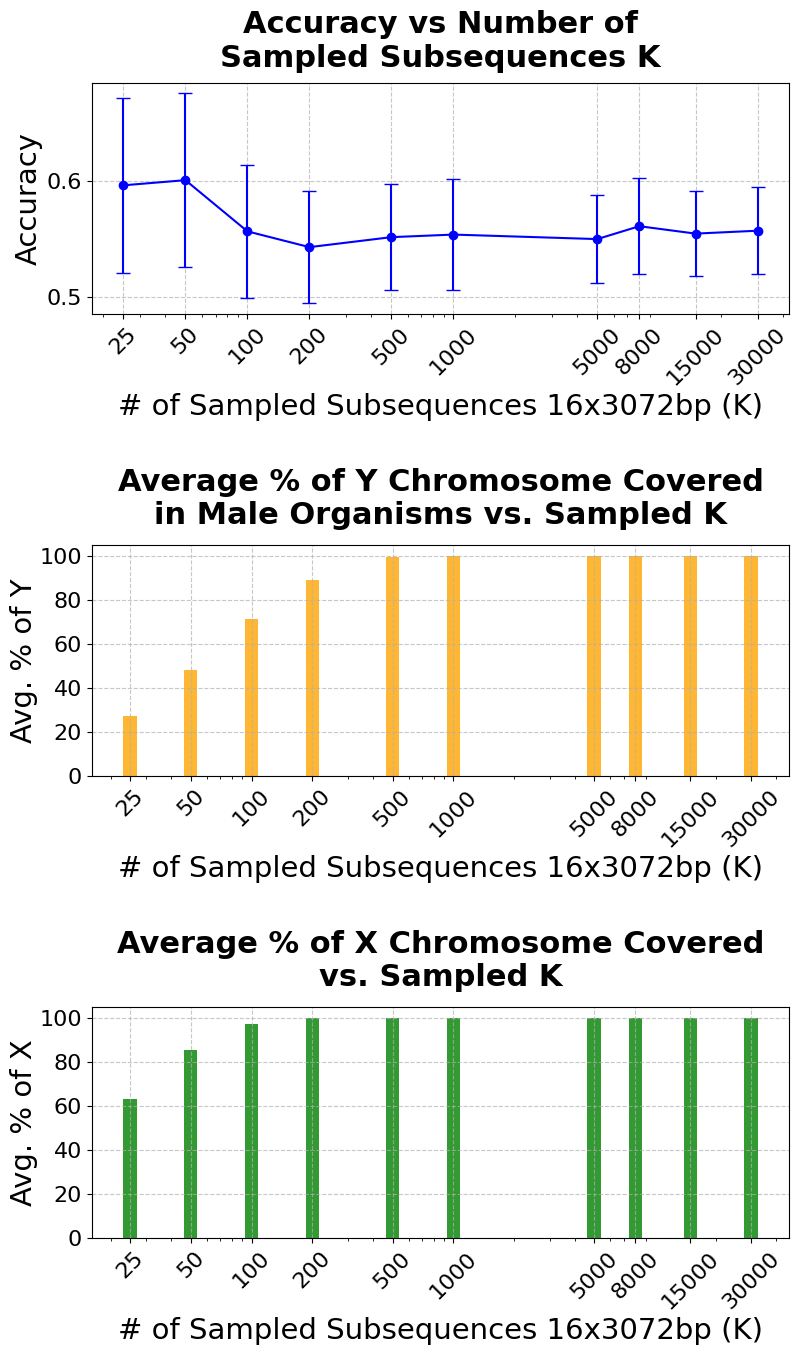

In [62]:
plot_error_bar(valid_sample2labels, list(N2thr.keys()), accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio)

In [63]:
accs, stds, X_probs, Y_probs = calculate_metrics(test_sample2labels, test_sample2probs, test_sample2chromosomes, N2threshold=N2thr)

/tmp/ipykernel_2551/1347137424.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


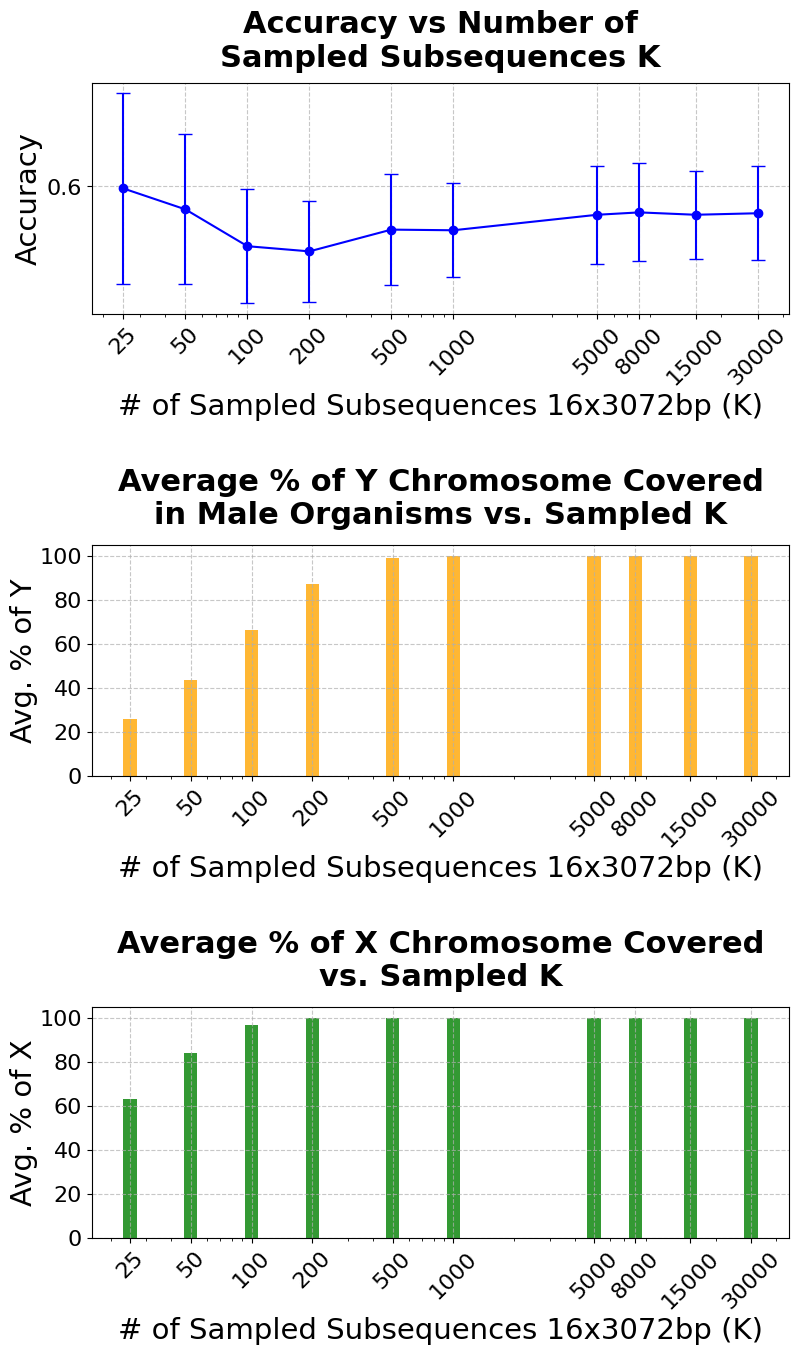

In [64]:
plot_error_bar(test_sample2labels, list(N2thr.keys()), accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio)

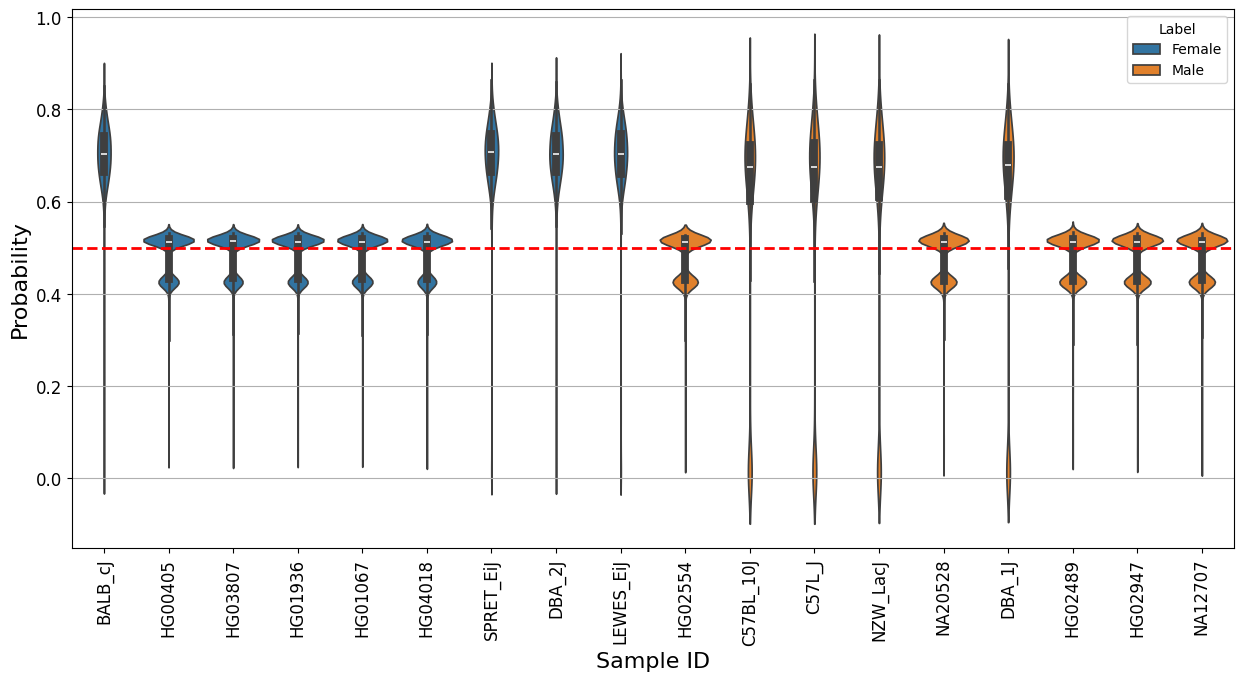

In [20]:
plot_violins(valid_sample2probs, valid_sample2labels, species_names, chrX_ratio, chrY_ratio)

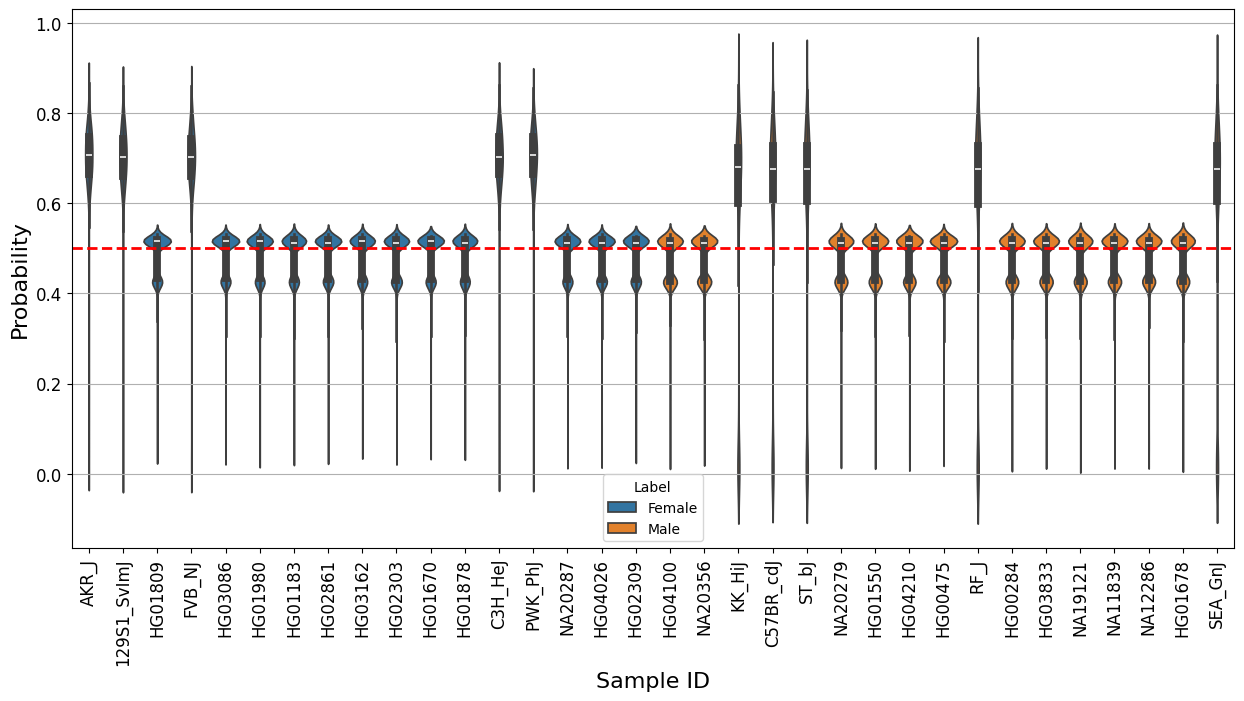

In [21]:
plot_violins(test_sample2probs, test_sample2labels, species_names, chrX_ratio, chrY_ratio)

## Mice

In [69]:
species_names = ['mus_musculus']

sample_ids_mouses = {sample_id: label for sample_id, label in valid_sample2labels.items() if sample_id in mouses_strains}
N2thr = find_threshold_for_N(sample_ids_mouses, valid_sample2probs)
accs, stds, X_probs, Y_probs = calculate_metrics(sample_ids_mouses, valid_sample2probs, valid_sample2chromosomes, N2threshold=N2thr)

/tmp/ipykernel_2551/1347137424.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


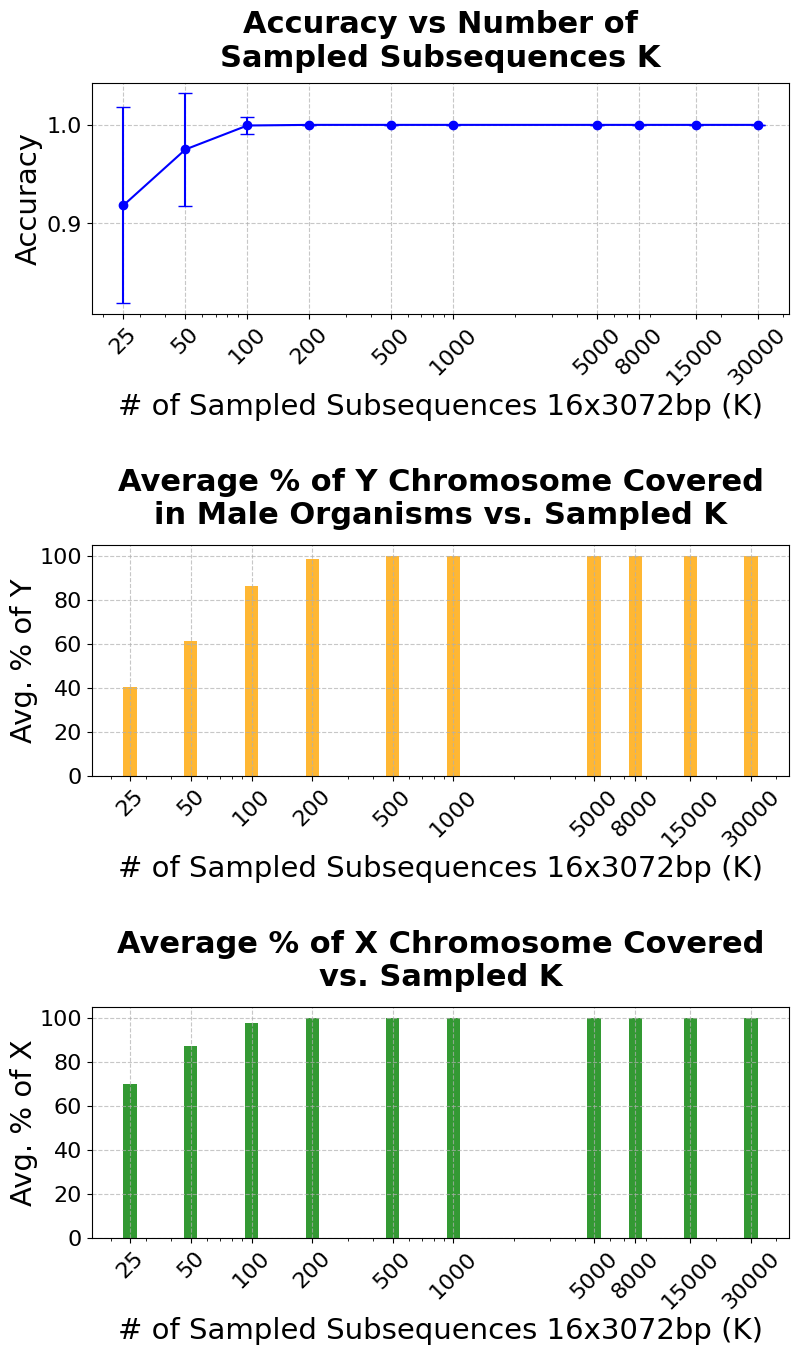

In [70]:
plot_error_bar(sample_ids_mouses, list(N2thr.keys()), accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio)

/tmp/ipykernel_2551/1347137424.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


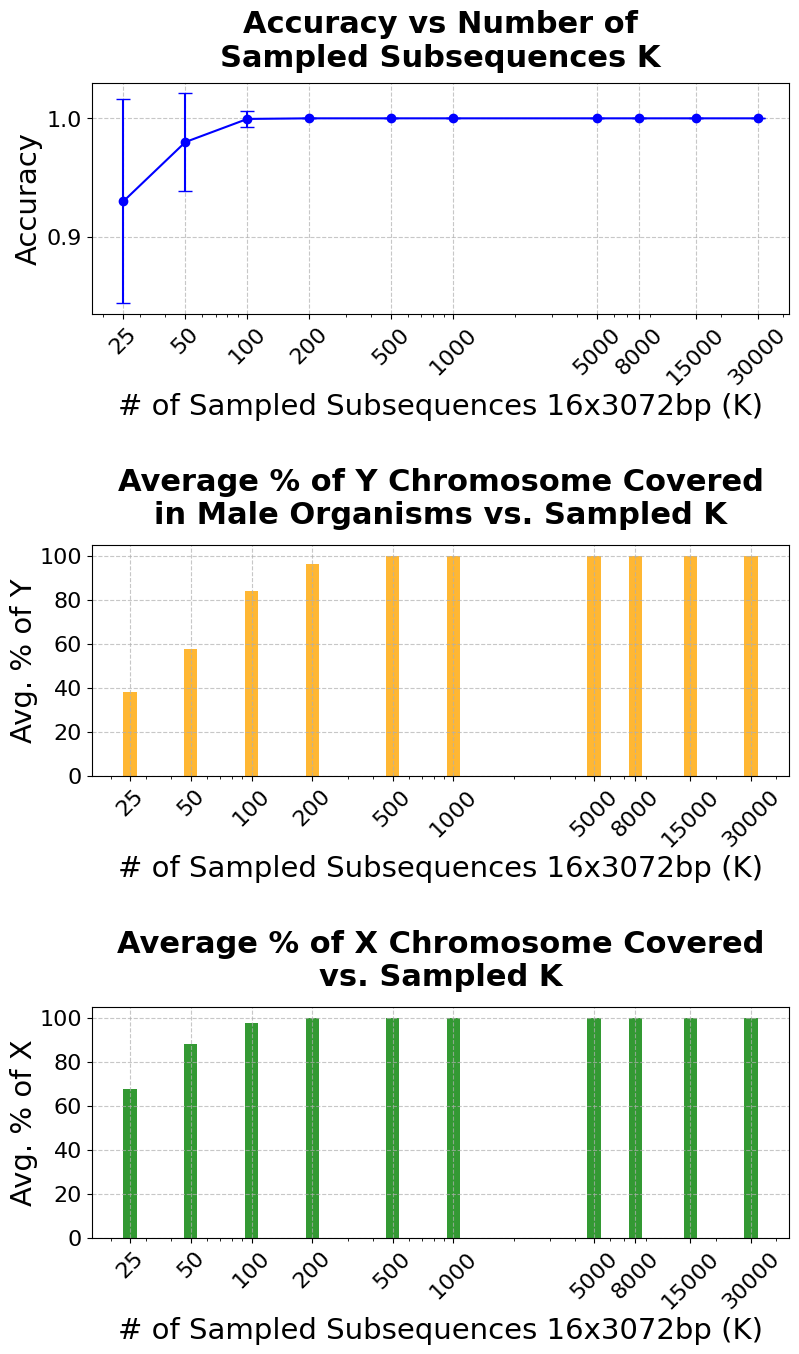

In [71]:
sample_ids_mouses = {sample_id: label for sample_id, label in test_sample2labels.items() if sample_id in mouses_strains}

accs, stds, X_probs, Y_probs = calculate_metrics(sample_ids_mouses, test_sample2probs, test_sample2chromosomes, N2threshold=N2thr)
plot_error_bar(sample_ids_mouses, list(N2thr.keys()), accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio)

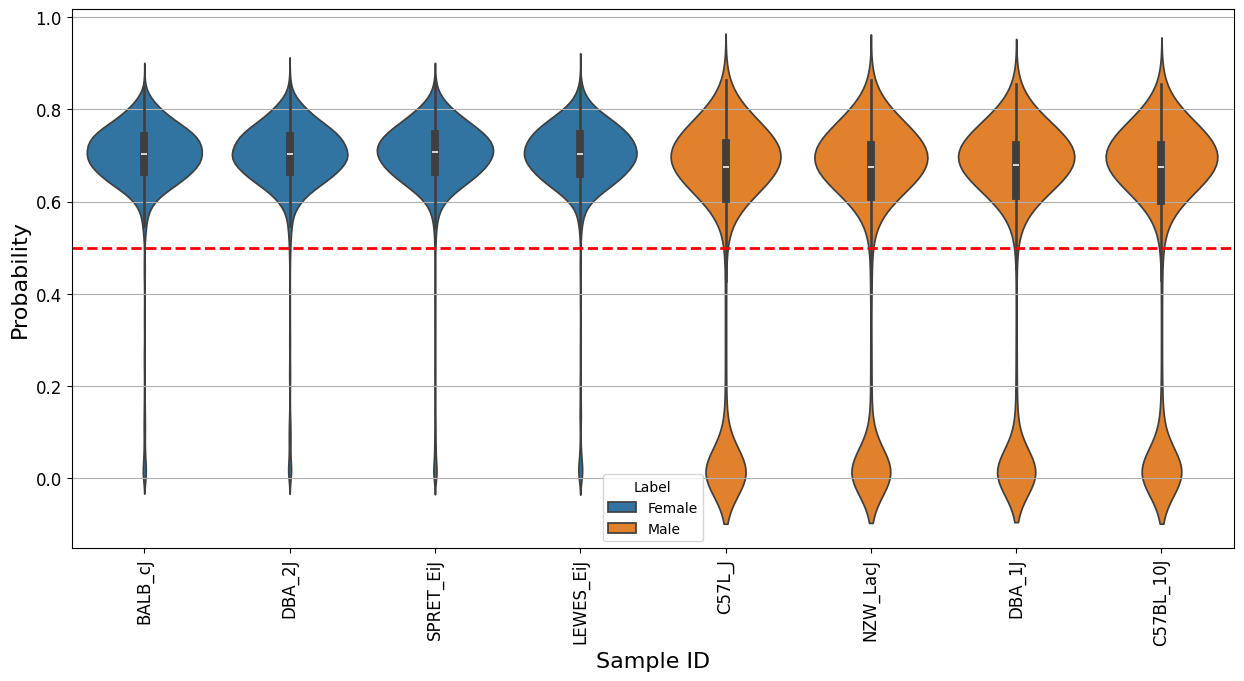

In [72]:
sample_ids_mouses = {sample_id: label for sample_id, label in valid_sample2labels.items() if sample_id in mouses_strains}
valid_sample2probs_mouses = {sample_id: prob for sample_id, prob in valid_sample2probs.items() if sample_id in mouses_strains}

plot_violins(valid_sample2probs_mouses, sample_ids_mouses, species_names, chrX_ratio, chrY_ratio)

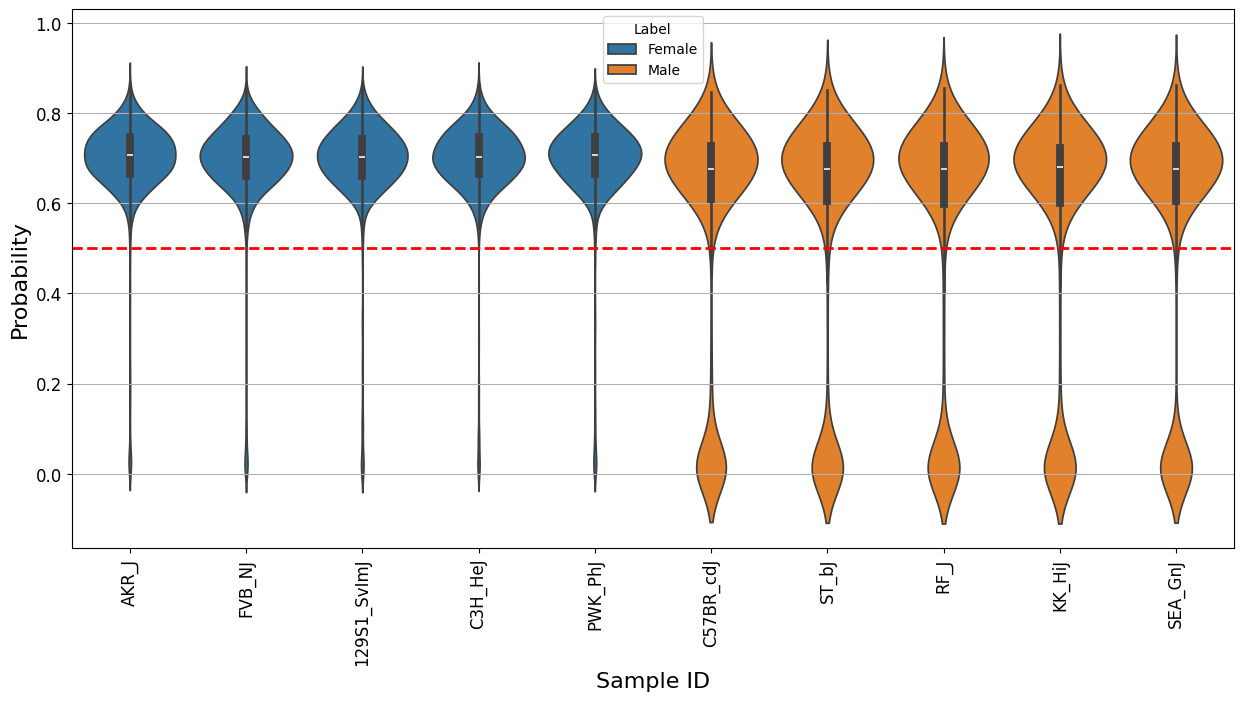

In [32]:
sample_ids_mouses = {sample_id: label for sample_id, label in test_sample2labels.items() if sample_id in mouses_strains}
test_sample2probs_mouses = {sample_id: prob for sample_id, prob in test_sample2probs.items() if sample_id in mouses_strains}

plot_violins(test_sample2probs_mouses, sample_ids_mouses, species_names, chrX_ratio, chrY_ratio)

## Humans

In [65]:
species_names = ['Homo_sapiens']
sample_ids_humans = {sample_id: label for sample_id, label in valid_sample2labels.items() if sample_id in human_ids}

N2thr = find_threshold_for_N(sample_ids_humans, valid_sample2probs)
accs, stds, X_probs, Y_probs = calculate_metrics(sample_ids_humans, valid_sample2probs, valid_sample2chromosomes, N2threshold=N2thr)

/tmp/ipykernel_2551/1347137424.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


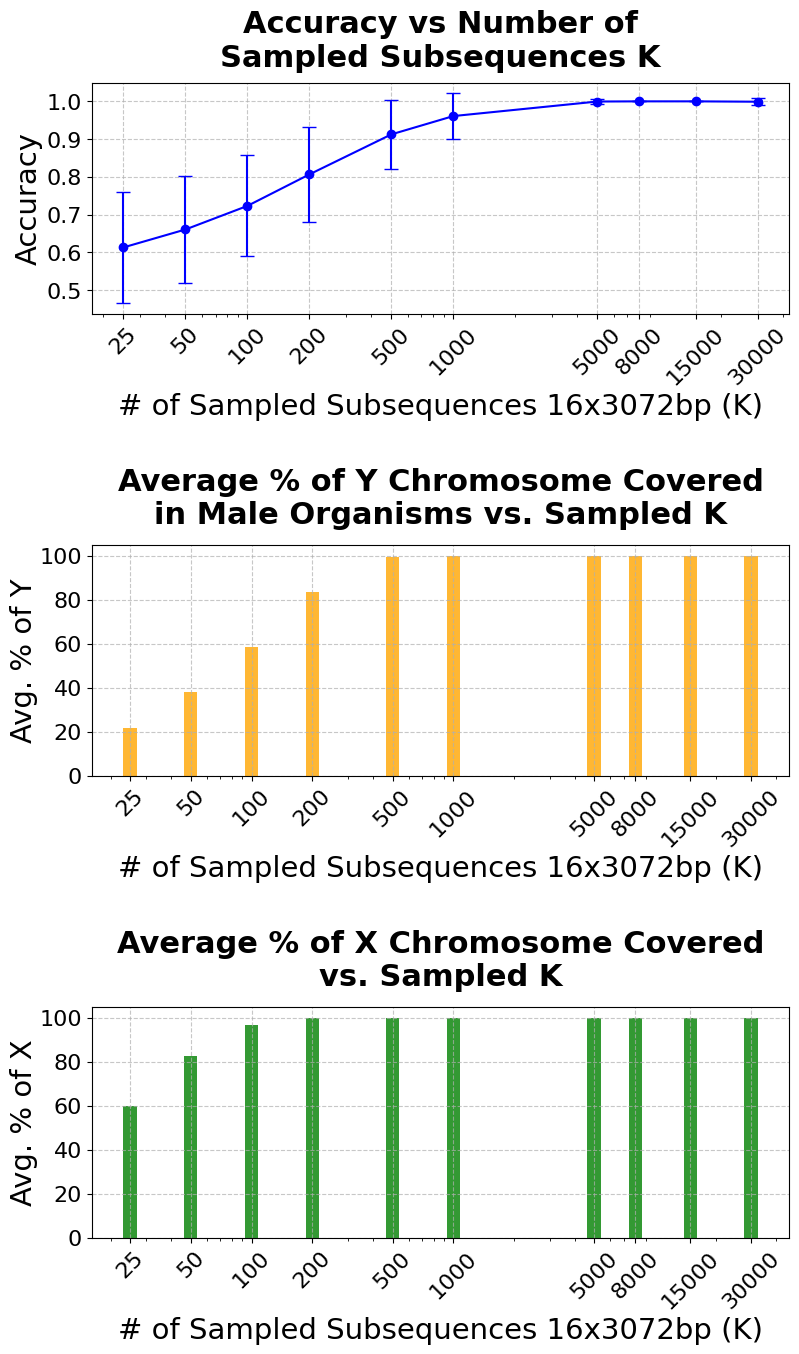

In [66]:
plot_error_bar(sample_ids_humans, list(N2thr.keys()), accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio)

In [67]:
species_names = ['Homo_sapiens']
sample_ids_humans = {sample_id: label for sample_id, label in test_sample2labels.items() if sample_id in human_ids}

# N2thr = find_threshold_for_N(sample_ids_humans, test_sample2probs)
accs, stds, X_probs, Y_probs = calculate_metrics(sample_ids_humans, test_sample2probs, test_sample2chromosomes, N2threshold=N2thr)

/tmp/ipykernel_2551/1347137424.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


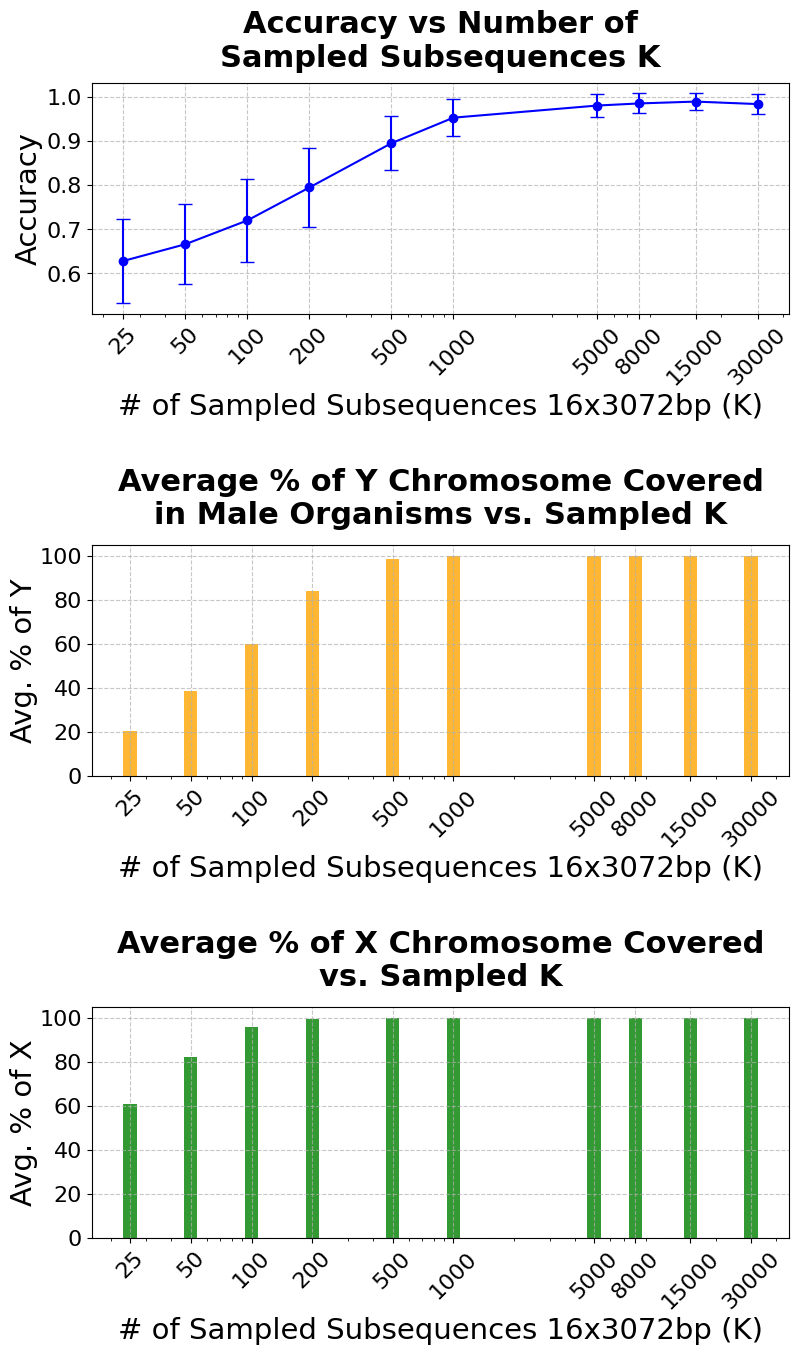

In [68]:
plot_error_bar(sample_ids_humans, list(N2thr.keys()), accs, stds, X_probs, Y_probs, species_names, chrX_ratio, chrY_ratio)

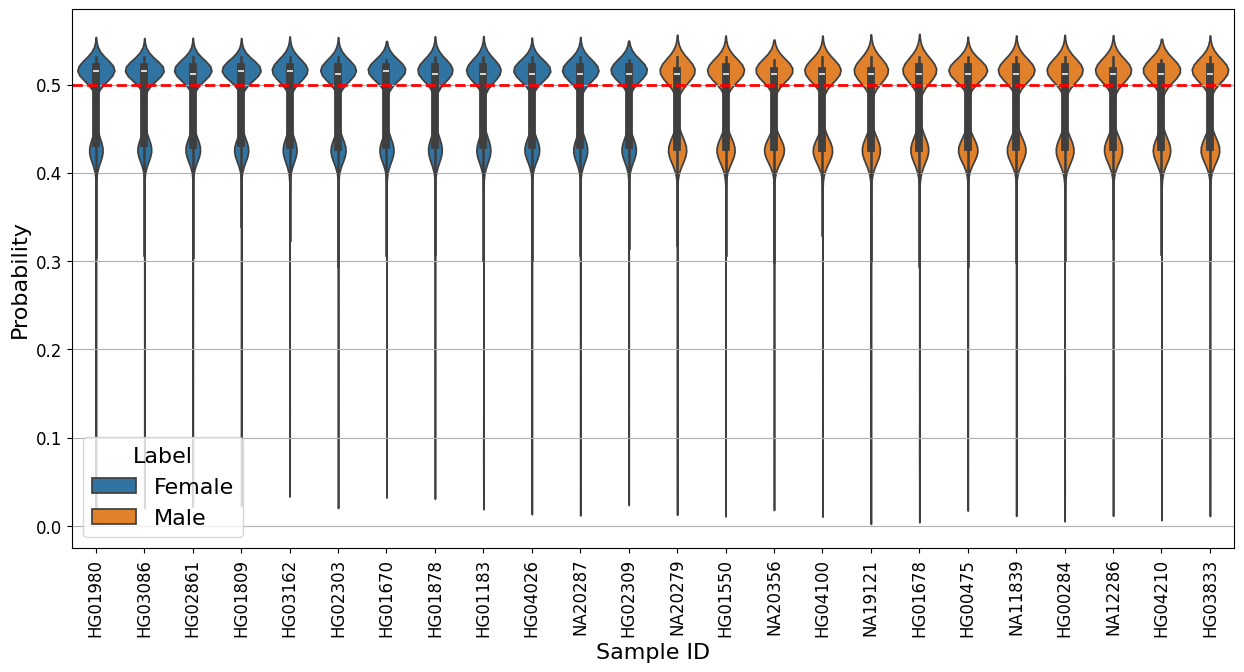

In [194]:
sample_ids_humans = {sample_id: label for sample_id, label in test_sample2labels.items() if sample_id in human_ids}
test_sample2probs_humans = {sample_id: prob for sample_id, prob in test_sample2probs.items() if sample_id in sample_ids_humans}

plot_violins(test_sample2probs_humans, sample_ids_humans, species_names, chrX_ratio, chrY_ratio)